# MATH 70116, Deep Learning
## Autumn 2026
## Lecturer: Tom Hadfield
# Universal Approximation Theorem

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

In [2]:
def g(x, beta = 10):
    return math.sin(beta*x)

# Apply the function using np.vectorize
vec_g = np.vectorize(g)

In [3]:
z = np.pi
print(z)

3.141592653589793


In [4]:
num_x = 10000
min_x = -np.pi
max_x = np.pi
beta = 5

X = np.random.uniform(min_x,max_x,num_x+1)
Y = vec_g(X,beta)

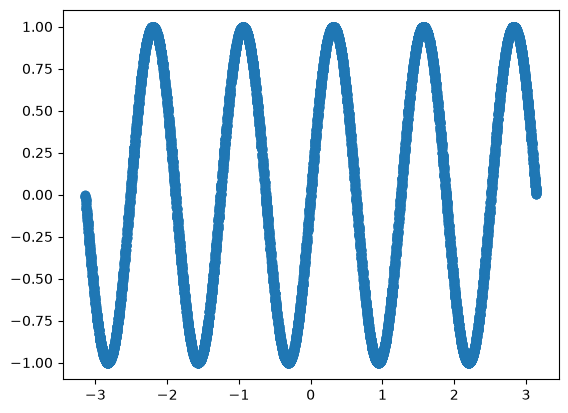

In [5]:
plt.scatter(X,Y)
plt.show()

### Now train a model with a single hidden layer to fit this data
<b>Important:</b> The methods <code>train_model</code>, <code>model_predict</code> are all defined below. Scroll down and run these cells first

In [6]:
# beta = 1 : hidden_dim = 100000, eta = 0.0002, num_epochs = 10
# beta = 1 : hidden_dim, eta, num_epochs = 100, 0.001, 10
# beta = 2 : hidden_dim, eta, num_epochs = 100, 0.001, 10
# beta = 5 : hidden_dim, eta, num_epochs = 10000, 0.0005, 50
# beta = 5 : hidden_dim, eta, num_epochs = 1000, 0.0001, 200

hidden_dim, eta, num_epochs = 100, 0.0003, 500

f = nn.Sequential(
    nn.Linear(1, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, 1)
)

In [7]:
optimizer = torch.optim.Adam(f.parameters(), lr=eta)
loss_fn = nn.MSELoss()

In [11]:
train = train_model(
    f,
    X,
    Y,
    loss_fn,
    optimizer,
    epochs=num_epochs,
    batch_size=32,
    validation_split=0.2,
    verbose_every=1)

n_total =  10001 n_val =  2000 n_train =  8001
Epoch 1/500, loss: 0.4916, val_loss: 0.4730
Epoch 2/500, loss: 0.4756, val_loss: 0.4689
Epoch 3/500, loss: 0.4691, val_loss: 0.4588
Epoch 4/500, loss: 0.4629, val_loss: 0.4536
Epoch 5/500, loss: 0.4574, val_loss: 0.4473
Epoch 6/500, loss: 0.4519, val_loss: 0.4419
Epoch 7/500, loss: 0.4464, val_loss: 0.4381
Epoch 8/500, loss: 0.4415, val_loss: 0.4321
Epoch 9/500, loss: 0.4369, val_loss: 0.4271
Epoch 10/500, loss: 0.4327, val_loss: 0.4227
Epoch 11/500, loss: 0.4277, val_loss: 0.4187
Epoch 12/500, loss: 0.4242, val_loss: 0.4150
Epoch 13/500, loss: 0.4190, val_loss: 0.4107
Epoch 14/500, loss: 0.4156, val_loss: 0.4053
Epoch 15/500, loss: 0.4106, val_loss: 0.4022
Epoch 16/500, loss: 0.4065, val_loss: 0.3992
Epoch 17/500, loss: 0.4024, val_loss: 0.3931
Epoch 18/500, loss: 0.3981, val_loss: 0.3910
Epoch 19/500, loss: 0.3940, val_loss: 0.3846
Epoch 20/500, loss: 0.3899, val_loss: 0.3835
Epoch 21/500, loss: 0.3867, val_loss: 0.3782
Epoch 22/500, los

In [12]:
Y_pred = model_predict(f,X)

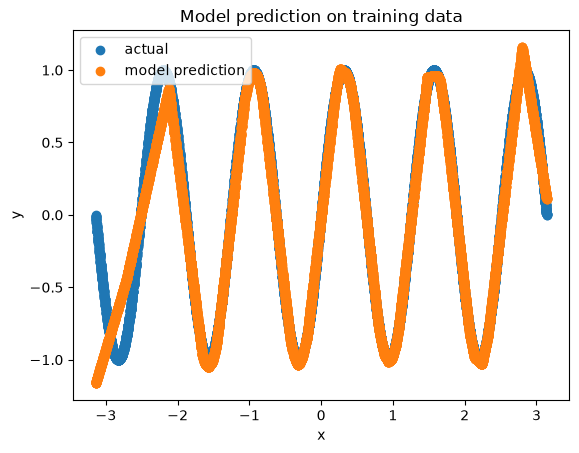

In [13]:
this_title = "Model prediction on training data"

plt.scatter(X, Y, label = "actual")
plt.scatter(X, Y_pred, label = "model prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title(this_title)
plt.show()

### evaluate on some new data

In [14]:
X_new = np.random.uniform(2.0 * min_x, 2.0 * max_x,num_x+1)
Y_new = vec_g(X_new,beta)
Y_pred_new = model_predict(f,X_new)

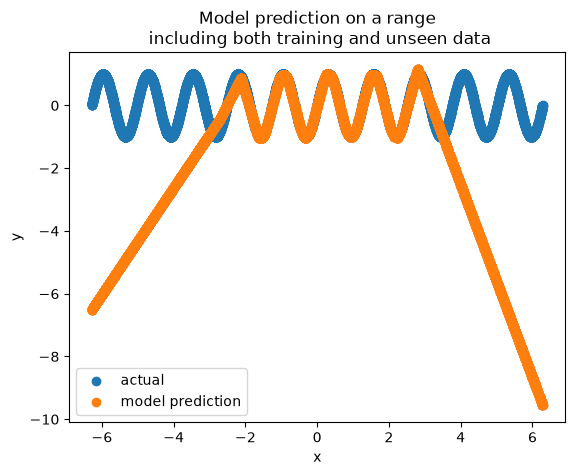

In [15]:
this_title = "Model prediction on a range"
this_title += "\n including both training and unseen data"

plt.scatter(X_new, Y_new, label = "actual")
plt.scatter(X_new, Y_pred_new, label = "model prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title(this_title)
plt.show()

### Exercise : repeat the above for beta = 10. What hidden_dim do you need to get good results?

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

def train_model(
    model,
    X,
    y,
    loss_fn,
    optimizer,
    epochs=100,
    batch_size=32,
    metrics=None,
    X_val=None,
    y_val=None,
    validation_split=0.0,
    verbose_every=10,
    device=None,
):
    """
    Generic training loop for a PyTorch model.

    Parameters
    ----------
    model : nn.Module
    X, y : torch.Tensor or np.ndarray  -- training data
    loss_fn : callable, e.g. nn.MSELoss(), nn.BCELoss()
    optimizer : torch.optim.Optimizer
    epochs : int
    batch_size : int
    metrics : dict[str, callable] or None
        Each callable takes (y_pred, y_true) and returns a float.
    X_val, y_val : optional validation data (same format as X, y)
        validation_split : float in [0.0, 1.0)
        Fraction of (X, y) to hold out as validation data, taken from the END of the dataset. 
        Ignored if X_val and y_val are both explicitly provided.
    verbose_every : int -- print progress every N epochs (0 to disable)
    device : torch.device or None -- defaults to CUDA if available, else CPU

    Returns
    -------
    history : dict of lists, e.g. {"loss": [...], "val_loss": [...], "accuracy": [...]}
    """
    if not (0.0 <= validation_split < 1.0):
        raise ValueError("validation_split must be in [0.0, 1.0)")

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    def to_tensor(a):
        if isinstance(a, np.ndarray):
            return torch.from_numpy(a).float()
        return a.float()

    X = to_tensor(X)
    #X = (to_tensor(X)).unsqueeze(-1)
    y = (to_tensor(y)).unsqueeze(-1)

    # Handle validation_split (only if X_val/y_val not already given)
    if X_val is None and y_val is None and validation_split > 0.0:
        n_total = X.shape[0]
        n_val = int(round(n_total * validation_split))
        n_train = n_total - n_val

        X_val = X[n_train:]
        y_val = y[n_train:]
        X = X[:n_train]
        y = y[:n_train]
        print("n_total = ", n_total, "n_val = ", n_val, "n_train = ", n_train)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    has_val = X_val is not None and y_val is not None
    if has_val:
        X_val = to_tensor(X_val).to(device)
        y_val = to_tensor(y_val).to(device)

    metrics = metrics or {}

    history = {"loss": []}
    history.update({name: [] for name in metrics})
    if has_val:
        history["val_loss"] = []
        history.update({f"val_{name}": [] for name in metrics})

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_metrics = {name: 0.0 for name in metrics}
        n_samples = 0

        i = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            i += 1

            #X_batch = X_batch.unsqueeze(-1)
            #print("X_batch.shape = ", X_batch.shape)
            y_pred = model(X_batch.unsqueeze(-1))
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = X_batch.size(0)
            running_loss += loss.item() * bs
            for name, fn in metrics.items():
                running_metrics[name] += fn(y_pred, y_batch) * bs
            n_samples += bs

        epoch_loss = running_loss / n_samples
        history["loss"].append(epoch_loss)
        for name in metrics:
            val = running_metrics[name] / n_samples
            history[name].append(val)

        log_str = f"Epoch {epoch+1}/{epochs}, loss: {epoch_loss:.4f}"
        for name in metrics:
            log_str += f", {name}: {history[name][-1]:.4f}"
            
        if has_val:
            model.eval()
            with torch.no_grad():
                y_val_pred = model(X_val.unsqueeze(-1))
                val_loss = loss_fn(y_val_pred, y_val).item()
                history["val_loss"].append(val_loss)
                log_str += f", val_loss: {val_loss:.4f}"
                for name, fn in metrics.items():
                    val_metric = fn(y_val_pred, y_val)
                    history[f"val_{name}"].append(val_metric)
                    log_str += f", val_{name}: {val_metric:.4f}"

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(log_str)

    return history

In [10]:
def model_predict(model, input_data):

	is_numpy_array = isinstance(input_data, np.ndarray)
	

	# 1. Make sure input_data is a float32 tensor
	if is_numpy_array:
		input_data = torch.from_numpy(input_data).float()
	else:
		input_data = input_data.float()

	# 2. Make sure it's on the same device as the model
	device = next(model.parameters()).device
	input_data = input_data.to(device)

	# 3. Set eval mode and disable gradient tracking for inference
	model.eval()
	with torch.no_grad():
		ppred = model(input_data.unsqueeze(-1))
		
	# 4. return as either numpy array or as tensor, depending on input type
	if is_numpy_array:
		# return as a numpy array
		ppred_np = ppred.cpu().numpy()
		return ppred_np
	else:
		return ppred